In [1]:
#Этап 1. EDA - загрузка данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

# Загрузка данных
ingredients_df = pd.read_csv('data/ingredients.csv')
dish_df = pd.read_csv('data/dish.csv')

print("Информация о таблице ingredients:")
print(ingredients_df.info())
print("\nПервые 5 строк ingredients:")
print(ingredients_df.head())

print("\nИнформация о таблице dish:")
print(dish_df.info())
print("\nПервые 5 строк dish:")
print(dish_df.head())


Информация о таблице ingredients:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB
None

Первые 5 строк ingredients:
   id            ingr
0   1  cottage cheese
1   2    strawberries
2   3    garden salad
3   4           bacon
4   5        potatoes

Информация о таблице dish:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB

In [2]:
#Этап 1. EDA - объединение таблиц
# Создаём словарь для сопоставления ID и названий ингредиентов
ingr_dict = dict(zip(ingredients_df['id'], ingredients_df['ingr']))

def replace_ids_with_names(ingr_ids):
    """Заменяет ID ингредиентов на названия"""
    if pd.isna(ingr_ids):
        return []

    ids_list = ingr_ids.split(';')
    names_list = []
    
    for id_str in ids_list:
        # Удаляем префикс 'ingr_' и преобразуем в число
        try:
            numeric_id = int(id_str[5:])  # берём символы с 5‑го индекса до конца
            name = ingr_dict.get(numeric_id, 'unknown')
            names_list.append(name)
        except ValueError:
            names_list.append('unknown')
    
    return ";".join(names_list)

# Применяем функцию к колонке ingredients
dish_df['ingredient_names'] = dish_df['ingredients'].apply(replace_ids_with_names)

# Удаляем колонку с ID ингредиентов, оставляем только названия
# dish_df.drop('ingredients', axis=1, inplace=True)

print("Первые 5 строк объединённой таблицы:")
print(dish_df[['dish_id', 'total_calories', 'total_mass', 'ingredient_names']].head())


Первые 5 строк объединённой таблицы:
           dish_id  total_calories  total_mass  \
0  dish_1561662216      300.794281       193.0   
1  dish_1561662054      419.438782       292.0   
2  dish_1562008979      382.936646       290.0   
3  dish_1560455030       20.590000       103.0   
4  dish_1558372433       74.360001       143.0   

                                    ingredient_names  
0  soy sauce;garlic;white rice;parsley;onions;bro...  
1  pepper;white rice;mixed greens;garlic;soy sauc...  
2  jalapenos;lemon juice;pork;wheat berry;cabbage...  
3             cherry tomatoes;cucumbers;baby carrots  
4                                         deprecated  


Статистика по калорийности:
count    3262.000000
mean      255.012738
std       219.637570
min         0.000000
25%        80.114996
50%       209.110062
75%       375.122963
max      3943.325195
Name: total_calories, dtype: float64

Статистика по массе:
count    3262.000000
mean      214.980074
std       161.497428
min         1.000000
25%        92.000000
50%       177.000000
75%       305.000000
max      3051.000000
Name: total_mass, dtype: float64


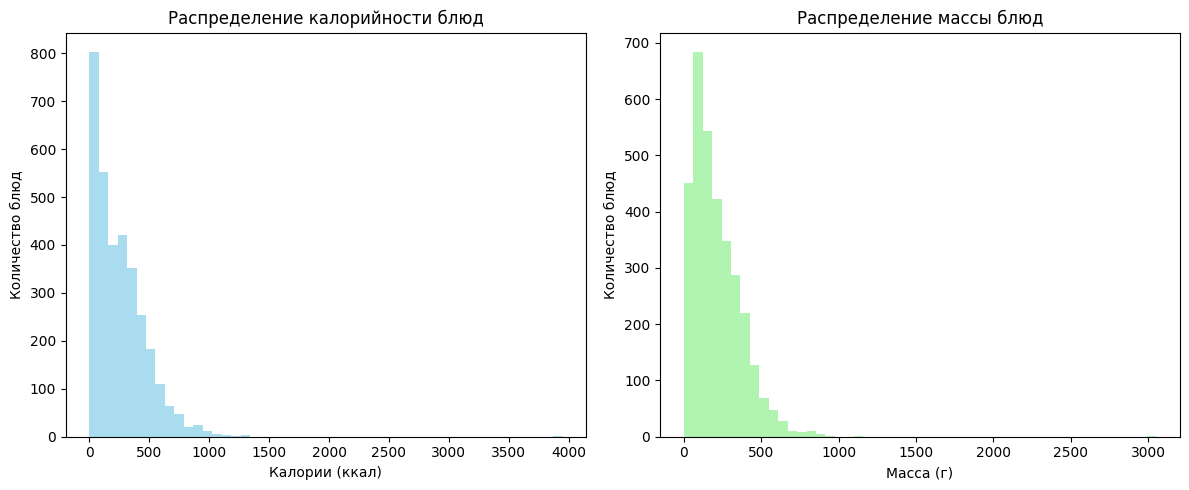

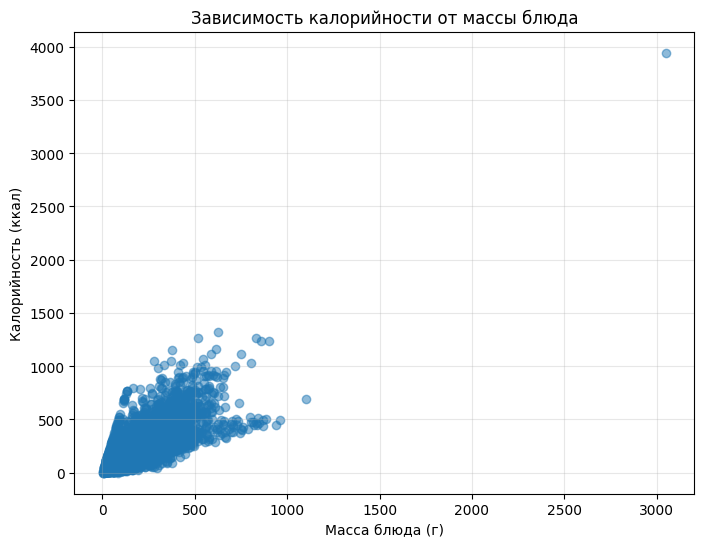

In [3]:
#Этап 1. EDA - Анализ распределения калорийности блюд
# Основные статистики по калорийности и массе
print("Статистика по калорийности:")
print(dish_df['total_calories'].describe())

print("\nСтатистика по массе:")
print(dish_df['total_mass'].describe())

# Визуализация распределений
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(dish_df['total_calories'], bins=50, color='skyblue', alpha=0.7)
axes[0].set_title('Распределение калорийности блюд')
axes[0].set_xlabel('Калории (ккал)')
axes[0].set_ylabel('Количество блюд')

axes[1].hist(dish_df['total_mass'], bins=50, color='lightgreen', alpha=0.7)
axes[1].set_title('Распределение массы блюд')
axes[1].set_xlabel('Масса (г)')
axes[1].set_ylabel('Количество блюд')

plt.tight_layout()
plt.show()

# Корреляция между массой и калорийностью
plt.figure(figsize=(8, 6))
plt.scatter(dish_df['total_mass'], dish_df['total_calories'], alpha=0.5)
plt.xlabel('Масса блюда (г)')
plt.ylabel('Калорийность (ккал)')
plt.title('Зависимость калорийности от массы блюда')
plt.grid(True, alpha=0.3)
plt.show()


Общее количество уникальных ингредиентов: 199
Топ-20 самых частых ингредиентов:
olive oil: 1561 раз
salt: 1379 раз
garlic: 947 раз
pepper: 723 раз
vinegar: 713 раз
onions: 686 раз
lemon juice: 572 раз
arugula: 506 раз
parsley: 493 раз
cherry tomatoes: 481 раз
spinach (raw): 437 раз
carrot: 432 раз
shallots: 402 раз
broccoli: 398 раз
mustard: 374 раз
cucumbers: 329 раз
mixed greens: 319 раз
chicken: 306 раз
thyme: 297 раз
wheat berry: 296 раз


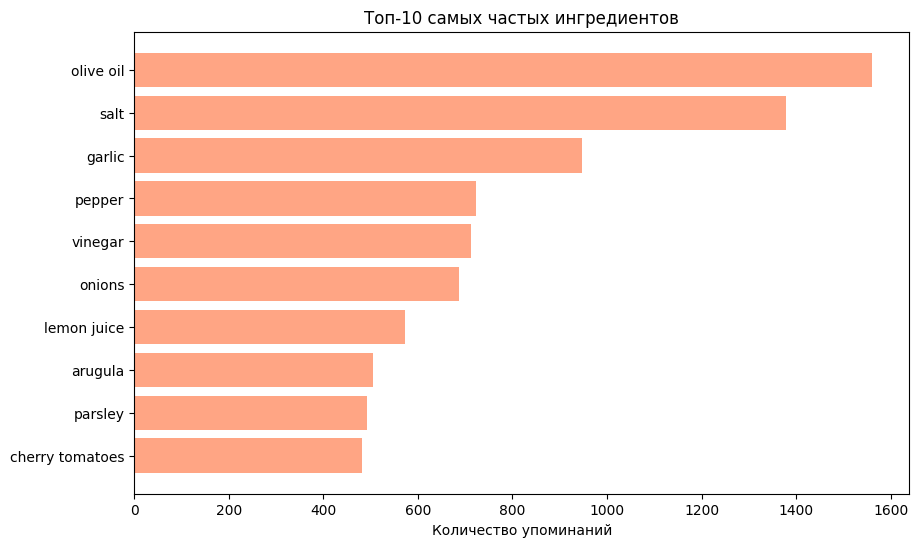

In [4]:
#Этап 1. EDA - Анализ текстовых данных
# Количество уникальных ингредиентов
all_ingredients = set()
for ingr_list in dish_df['ingredient_names']:
    all_ingredients.update(ingr_list.split(";"))
print(f"Общее количество уникальных ингредиентов: {len(all_ingredients)}")

# Топ-20 самых частых ингредиентов
from collections import Counter

ingredient_counter = Counter()
for ingr_list in dish_df['ingredient_names']:
    ingredient_counter.update(ingr_list.split(";"))

top_ingredients = ingredient_counter.most_common(20)
print("Топ-20 самых частых ингредиентов:")
for ingredient, count in top_ingredients:
    print(f"{ingredient}: {count} раз")

# Визуализация топ-10 ингредиентов
top_10 = ingredient_counter.most_common(10)
ingredients, counts = zip(*top_10)

plt.figure(figsize=(10, 6))
plt.barh(ingredients, counts, color='coral', alpha=0.7)
plt.xlabel('Количество упоминаний')
plt.title('Топ-10 самых частых ингредиентов')
plt.gca().invert_yaxis()
plt.show()


Всего блюд: 3262
Блюд с изображениями: 3262
Процент блюд с изображениями: 100.00%


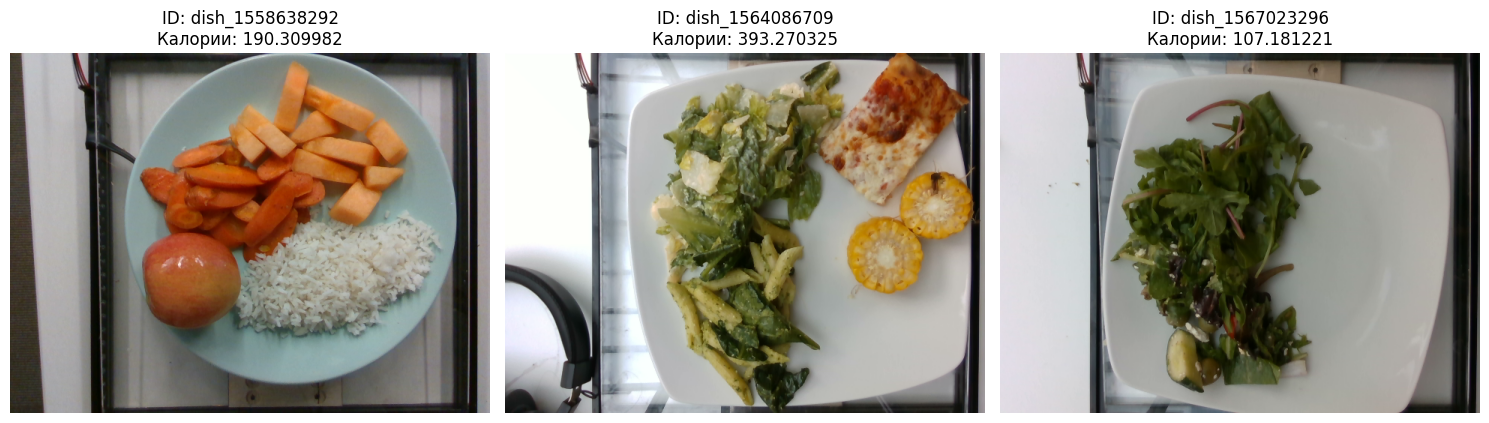

In [5]:
#Этап 1. EDA - Проверка наличия фотографии у блюда
def check_image_availability(dish_id):
    """Проверяет наличие изображения для dish_id"""
    img_path = os.path.join("data", "images", str(dish_id), "rgb.png")
    return os.path.exists(img_path)

dish_df['image_available'] = dish_df['dish_id'].apply(check_image_availability)

print(f"Всего блюд: {len(dish_df)}")
print(f"Блюд с изображениями: {dish_df['image_available'].sum()}")
print(f"Процент блюд с изображениями: {dish_df['image_available'].mean() * 100:.2f}%")

# Просмотр нескольких примеров изображений
sample_dishes = dish_df[dish_df['image_available']].sample(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (idx, row) in enumerate(sample_dishes.iterrows()):
    img_path = os.path.join("data", "images", str(row['dish_id']), "rgb.png")
    image = Image.open(img_path).convert("RGB")
    axes[i].imshow(image)
    axes[i].set_title(f"ID: {row['dish_id']}\nКалории: {row['total_calories']}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


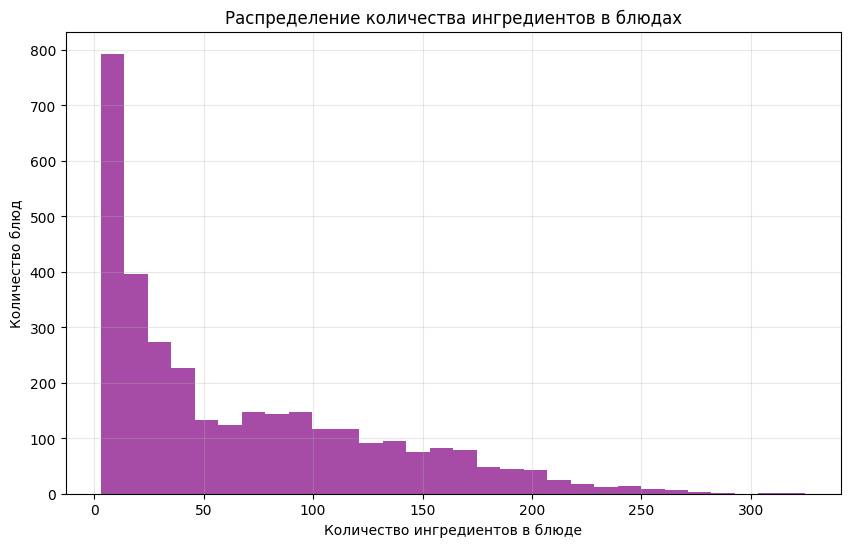

Статистика по количеству ингредиентов:
count    3262.000000
mean       66.415389
std        61.457644
min         3.000000
25%        14.000000
50%        43.000000
75%       106.000000
max       325.000000
Name: num_ingredients, dtype: float64


In [6]:
#Этап 1. EDA - Распределение количества ингредиентов в блюдах
dish_df['num_ingredients'] = dish_df['ingredient_names'].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(dish_df['num_ingredients'], bins=30, color='purple', alpha=0.7)
plt.xlabel('Количество ингредиентов в блюде')
plt.ylabel('Количество блюд')
plt.title('Распределение количества ингредиентов в блюдах')
plt.grid(True, alpha=0.3)
plt.show()

print("Статистика по количеству ингредиентов:")
print(dish_df['num_ingredients'].describe())



Распределение по сплитам:
split
train    2755
test      507
Name: count, dtype: int64

Статистика калорийности в train:
count    2755.000000
mean      254.929131
std       221.009051
min         0.000000
25%        81.805329
50%       208.115997
75%       376.573365
max      3943.325195
Name: total_calories, dtype: float64

Статистика калорийности в test:
count     507.000000
mean      255.467051
std       212.241674
min         0.000000
25%        74.360001
50%       226.014999
75%       369.684906
max      1050.511108
Name: total_calories, dtype: float64


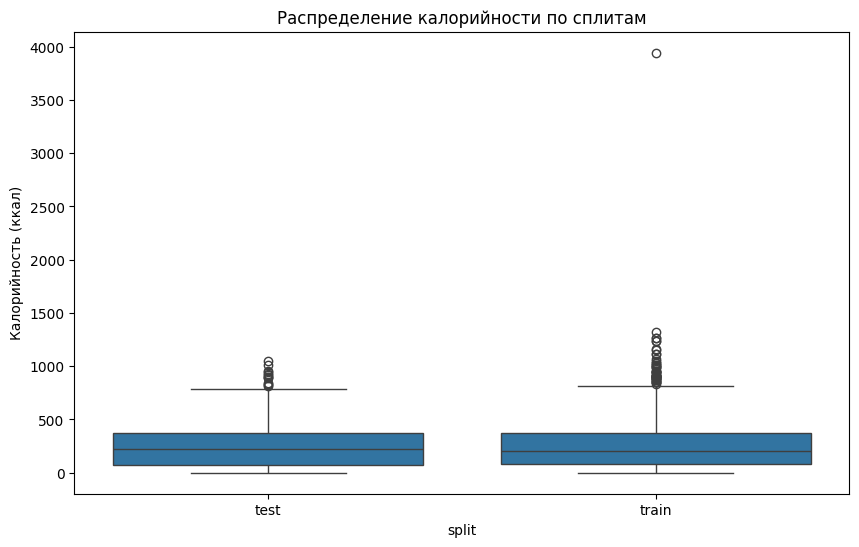

In [7]:
#Этап 1. EDA - Анализ разделения данных на train/test
split_counts = dish_df['split'].value_counts()
print("Распределение по сплитам:")
print(split_counts)

# Сравнение статистики по калорийности в train и test
train_data = dish_df[dish_df['split'] == 'train']
test_data = dish_df[dish_df['split'] == 'test']

print("\nСтатистика калорийности в train:")
print(train_data['total_calories'].describe())
print("\nСтатистика калорийности в test:")
print(test_data['total_calories'].describe())

# Визуализация распределения калорийности по сплитам
plt.figure(figsize=(10, 6))
sns.boxplot(data=dish_df, x='split', y='total_calories')
plt.title('Распределение калорийности по сплитам')
plt.ylabel('Калорийность (ккал)')
plt.show()


In [ ]:
#Выводы из EDA:

#Данные сбалансированы по сплитам — распределение калорийности в train и test схожее.

#Масса блюда коррелирует с калорийностью, но зависимость нелинейная — есть выбросы (например большая калорийность.).

#Изображения доступны для всех блюд — можно использовать мультимодальный подход.


In [9]:
#Этап 2
# scripts/dataset.py - работа с набором данных
# scripts/utils.py - модель, пайплайн обучения и валидации
# scrpts/analysis.py - функции анализа результатов

In [ ]:
#Этап 3 Обучение модели - настройки и подготовка данных

import torch
from transformers import AutoTokenizer

from scripts.dataset import get_dataloaders
from scripts.utils import FoodCaloriePredictor, seed_everything, train

class Cfg:
    # Основные параметры обучения
    NUM_EPOCHS = 20
    BATCH_SIZE = 4
    SEED = 42

    # Learning rates для разных частей модели
    TEXT_LR = 2e-5
    IMAGE_LR = 1e-4
    CLASSIFIER_LR = 1e-3
    WEIGHT_DECAY = 0.02

    # Пути к данным
    DATA_DIR = "data"
    IMAGE_DIR = os.path.join(DATA_DIR, "images")
    INGREDIENTS_CSV = os.path.join(DATA_DIR, "ingredients.csv")
    DISH_CSV = os.path.join(DATA_DIR, "dish.csv")

    # Параметры модели
    TEXT_MODEL_NAME = "bert-base-uncased"
    # IMAGE_MODEL_NAME = "tf_efficientnet_b0"
    # HIDDEN_DIM = 768
    # MAX_LENGTH = 128
    IMAGE_MODEL_NAME = "tf_efficientnet_b1"
    HIDDEN_DIM = 1024
    MAX_LENGTH = 256

    # Настройки устройства
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Сохранение модели
    SAVE_DIR = "saved_models"
    MODEL_NAME = "food_calorie_predictor.pth"
    SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)

    # Логирование
    LOG_INTERVAL = 50  # Интервал логирования батчей
    PRINT_EVERY = 1  # Печатать метрики каждые N эпох

# Инициализация конфигурации
cfg = Cfg()
seed_everything(cfg.SEED)

# Загрузка данных и создание даталоадеров
tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)
train_loader, val_loader, test_loader = get_dataloaders(cfg, dish_df, cfg.IMAGE_DIR, tokenizer, cfg.BATCH_SIZE)

In [11]:
#Этап 3 Обучение модели -запуск

import torch
from transformers import AutoTokenizer


# Создание модели
model = FoodCaloriePredictor(cfg.TEXT_MODEL_NAME, cfg.IMAGE_MODEL_NAME, cfg.HIDDEN_DIM)

# Запуск обучения
train(cfg, model, train_loader, val_loader, cfg.DEVICE)


model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

Epoch 1, Batch 0, Loss: 0.2806
Epoch 1, Batch 50, Loss: 0.2915
Epoch 1, Batch 100, Loss: 0.2358
Epoch 1, Batch 150, Loss: 0.0425
Epoch 1, Batch 200, Loss: 0.2977
Epoch 1, Batch 250, Loss: 0.2792
Epoch 1, Batch 300, Loss: 0.1218
Epoch 1, Batch 350, Loss: 0.0782
Epoch 1, Batch 400, Loss: 0.0905
Epoch 1, Batch 450, Loss: 0.0728
Epoch 1, Batch 500, Loss: 0.0958
Epoch 1, Batch 550, Loss: 0.3261
Модель сохранена с MAE: 0.1065
Epoch 1/20 | Train Loss: 0.1565 | Train MAE: 0.1565 | Val Loss: 0.1067 | Val MAE: 0.1065
Epoch 2, Batch 0, Loss: 0.1331
Epoch 2, Batch 50, Loss: 0.1544
Epoch 2, Batch 100, Loss: 0.0694
Epoch 2, Batch 150, Loss: 0.1862
Epoch 2, Batch 200, Loss: 0.1254
Epoch 2, Batch 250, Loss: 0.1656
Epoch 2, Batch 300, Loss: 0.0608
Epoch 2, Batch 350, Loss: 0.0390
Epoch 2, Batch 400, Loss: 0.1191
Epoch 2, Batch 450, Loss: 0.0753
Epoch 2, Batch 500, Loss: 0.1263
Epoch 2, Batch 550, Loss: 0.1257
Модель сохранена с MAE: 0.0910
Epoch 2/20 | Train Loss: 0.1289 | Train MAE: 0.1289 | Val Loss:

KeyboardInterrupt: 

Оценка модели на тестовой выборке...
ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:
Тестовая MAE: 72.03 ккал
Тестовая RMSE: 113.62 ккал
Целевая метрика: MAE < 50 ккал
⚠️  Цель не достигнута, отклонение: 22.03 ккал
Визуализация результатов...


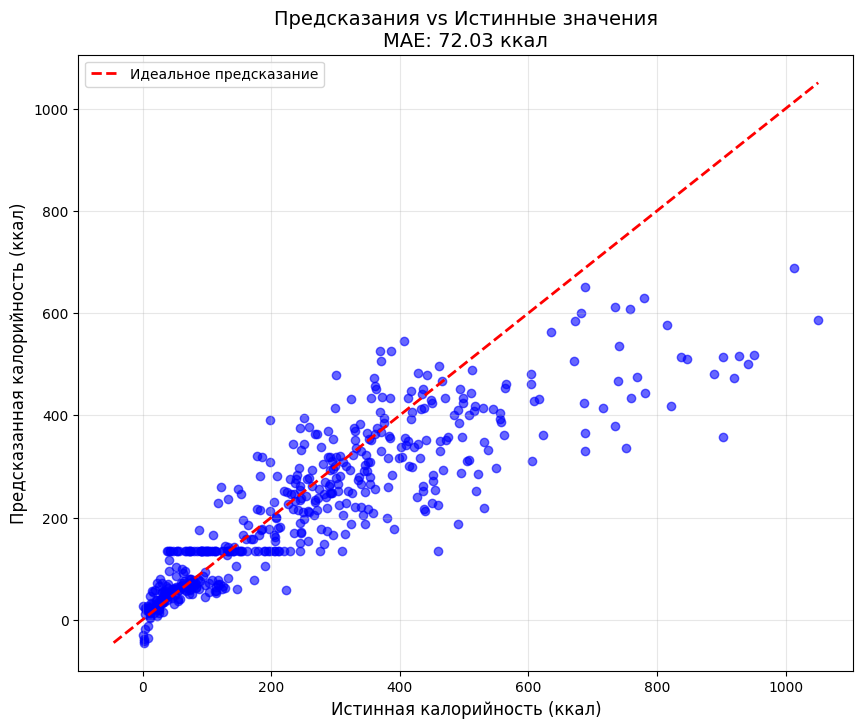

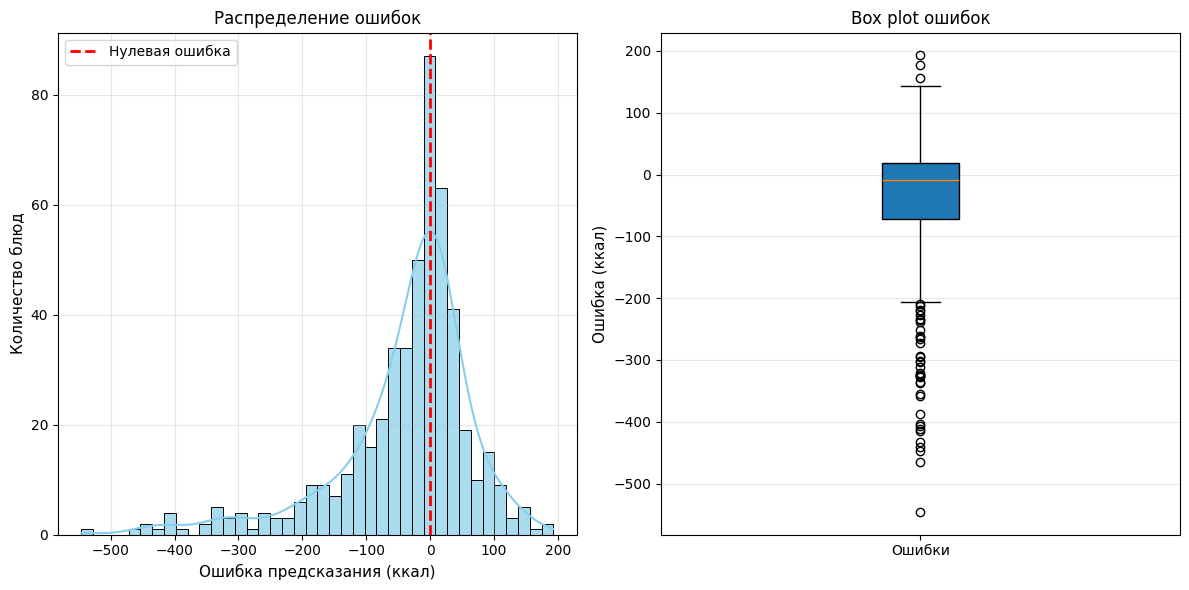


Статистика ошибок:
  Среднее:     -38.87 ккал
  Медиана:     -9.40 ккал
  Std:         106.76 ккал
  Мин:         -545.64 ккал
  Макс:        192.79 ккал

АНАЛИЗ ОШИБОК ПО ДИАПАЗОНАМ КАЛОРИЙНОСТИ:
                error              total_calories
                 mean    std count           mean
calorie_range                                    
0–150           27.30  26.69   204          64.85
150–300         52.60  41.20   119         233.55
300–500         85.50  67.38   124         388.30
500–800        193.45  95.20    46         620.32
800+           397.29  77.49    13         908.95


/home/ubuntu/project/scripts/analysis.py:172: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_range = test_df.groupby('calorie_range').agg({
/home/ubuntu/project/scripts/analysis.py:185: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_errors = test_df.groupby('calorie_range')['error'].mean()


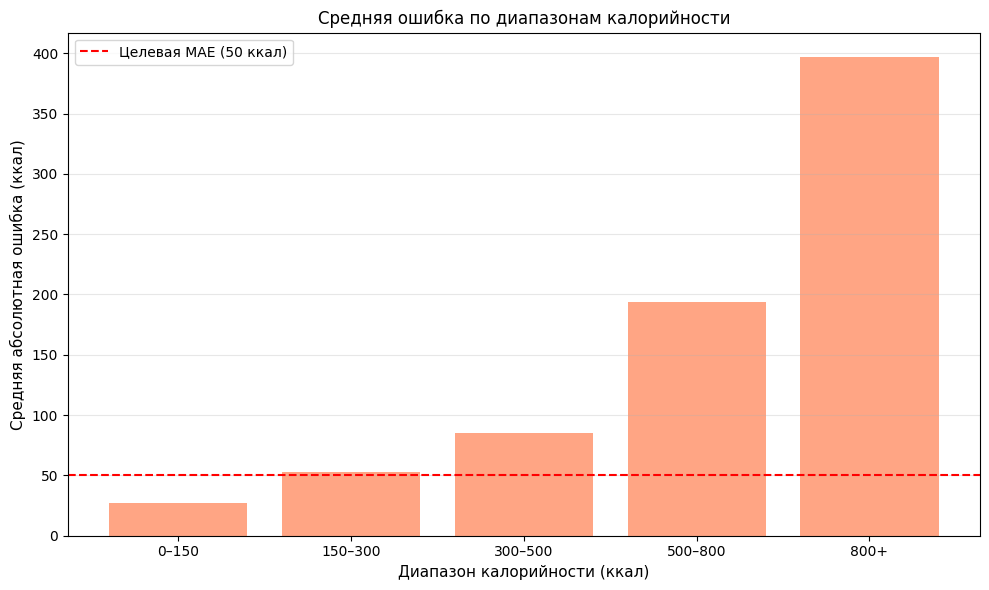


ТОП-5 ХУДШИХ ПРЕДСКАЗАНИЙ:

Блюдо ID: dish_1565811139
  Реальная калорийность: 902.2 ккал
  Предсказанная:         356.6 ккал
  Ошибка:                545.6 ккал (-545.6)
  Масса порции:          416 г

Блюдо ID: dish_1558375886
  Реальная калорийность: 1050.5 ккал
  Предсказанная:         585.7 ккал
  Ошибка:                464.8 ккал (-464.8)
  Масса порции:          277 г

Блюдо ID: dish_1566414412
  Реальная калорийность: 920.1 ккал
  Предсказанная:         472.5 ккал
  Ошибка:                447.6 ккал (-447.6)
  Масса порции:          658 г

Блюдо ID: dish_1566328831
  Реальная калорийность: 941.6 ккал
  Предсказанная:         501.0 ккал
  Ошибка:                440.6 ккал (-440.6)
  Масса порции:          500 г

Блюдо ID: dish_1563478751
  Реальная калорийность: 950.4 ккал
  Предсказанная:         517.8 ккал
  Ошибка:                432.6 ккал (-432.6)
  Масса порции:          545 г

ТОП-5 ЛУЧШИХ ПРЕДСКАЗАНИЙ:

Блюдо ID: dish_1558030289
  Реальная калорийность: 38.5 ккал
  Пред

/home/ubuntu/project/scripts/analysis.py:280: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/home/ubuntu/project/scripts/analysis.py:280: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/home/ubuntu/project/scripts/analysis.py:280: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/home/ubuntu/project/scripts/analysis.py:280: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/home/ubuntu/project/scripts/analysis.py:282: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/home/ubuntu/project/scripts/analysis.py:282: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaV


✅ Визуализация сохранена в: results/worst_predictions_analysis.png


/home/ubuntu/project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


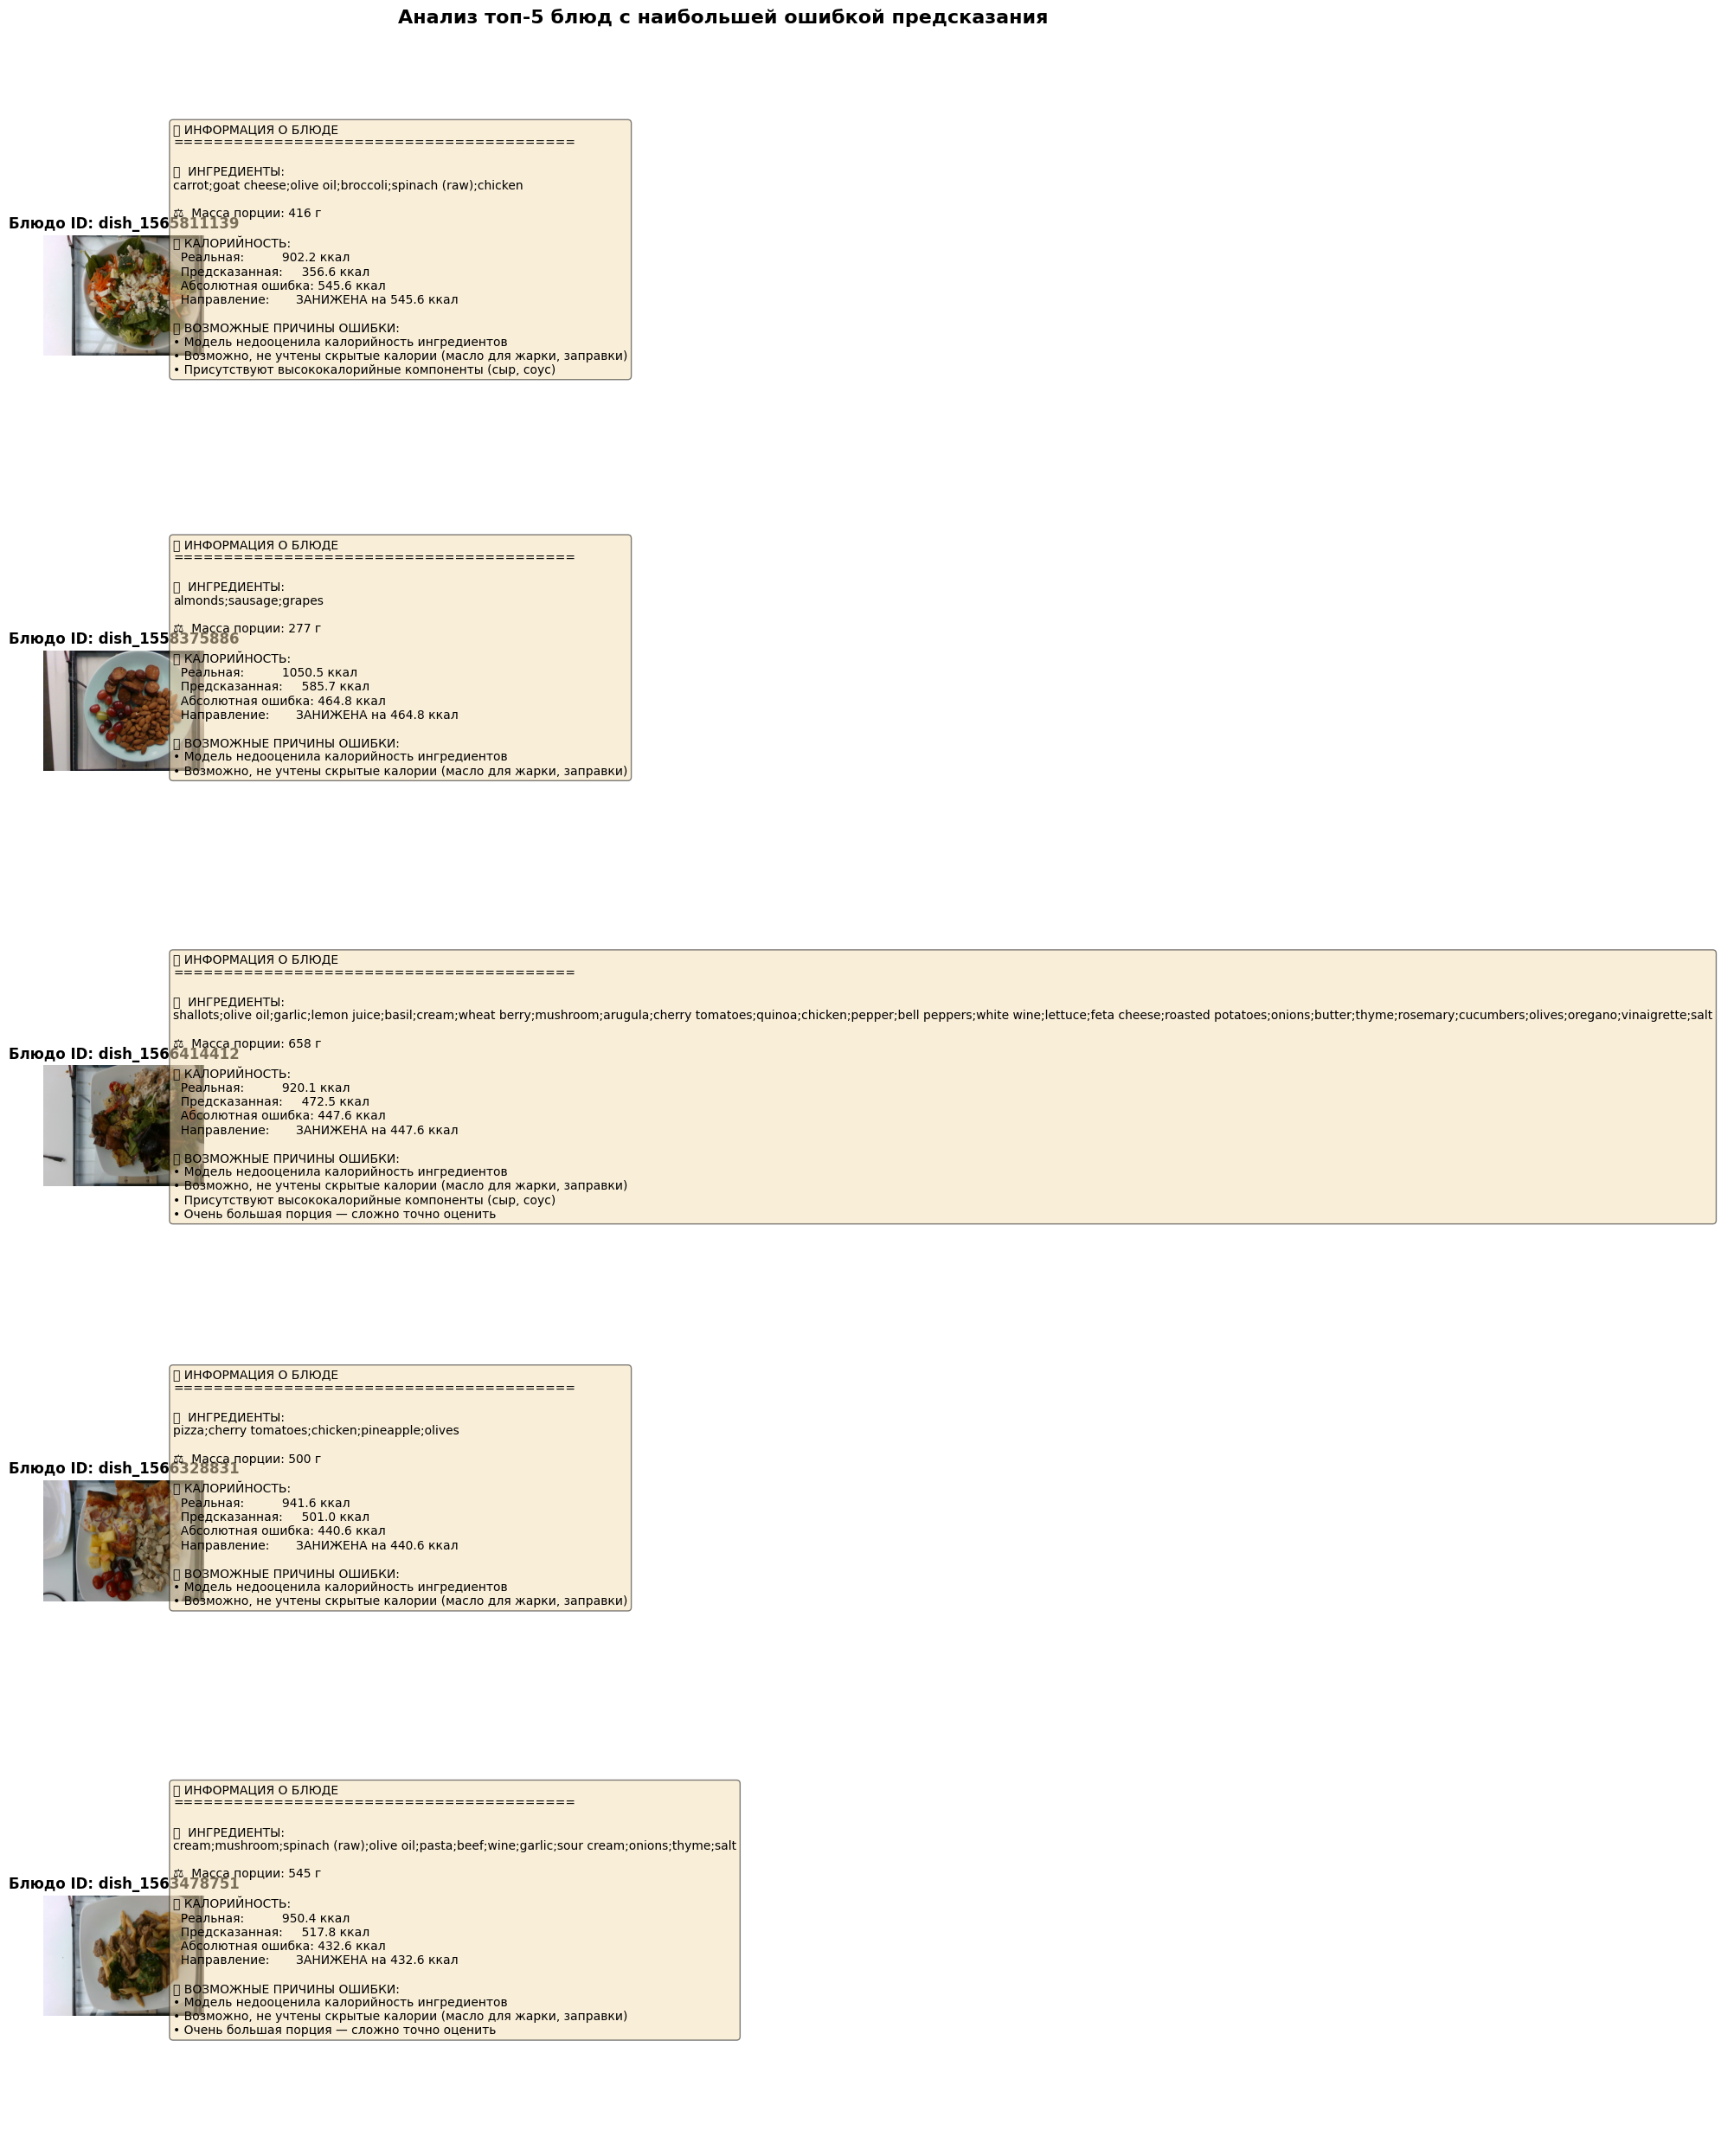


📝 ИТОГОВЫЙ АНАЛИЗ ОШИБОК МОДЕЛИ

1️⃣  ОБЩАЯ СТАТИСТИКА:
   • Средняя ошибка (MAE): 72.03 ккал
   • Целевая метрика:      MAE < 50 ккал
   • ⚠️  СТАТУС: Требуется доработка

2️⃣  ТИПИЧНЫЕ ПРИЧИНЫ ОШИБОК:
   • Размер порции: модель не всегда точно оценивает массу по фото
   • Скрытые ингредиенты: масло для жарки, заправки, специи
   • Способ приготовления: жарка vs запекание vs варка
   • Редкие блюда: мало примеров в обучающей выборке
   • Сложные блюда: много компонентов, трудно учесть все

3️⃣  РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:
   • Добавить признак массы порции как отдельный вход (уже сделано)
   • Увеличить датасет, особенно редких блюд
   • Добавить информацию о способе приготовления
   • Использовать более мощные энкодеры (EfficientNet-B3/B4)
   • Попробовать ансамбль моделей

4️⃣  НАИБОЛЕЕ ПРОБЛЕМНЫЕ КАТЕГОРИИ:
   • Блюда с молочными продуктами: 3 случаев
   • Разное: 2 случаев


✅ ЭТАП 4 ЗАВЕРШЁН УСПЕШНО!

📁 Результаты сохранены в папке 'results/'
   • predictions_vs_targets.png
   • 

In [13]:
#Этап 4 Оценка результата
# Ранее использовалась модель tf_efficientnet_b0, с которой на 20 эпохе MAE~0.055-0.06 (55-60 ккал).
# С b1 динамика MAE при обучении не отличается, потому обучение с новой моделью прервано вручную с лучшим MAE 0.055

from scripts.analysis import analyze_errors, evaluate_model, plot_predictions_vs_targets, plot_error_distribution, categorize_by_calorie_range, visualize_worst_predictions, print_final_analysis

# from scripts.utils import FoodCaloriePredictor
# model = FoodCaloriePredictor(
#     text_model_name=cfg.TEXT_MODEL_NAME,
#     image_model_name=cfg.IMAGE_MODEL_NAME,
#     hidden_dim=cfg.HIDDEN_DIM
# ).to(cfg.DEVICE)

# if os.path.exists(cfg.SAVE_PATH):
#     checkpoint = torch.load(cfg.SAVE_PATH, map_location=cfg.DEVICE)
#     model.load_state_dict(checkpoint)
#     print(f"Модель загружена ")
# else:
#     raise FileNotFoundError("Сохранённая модель не найдена")

print("Оценка модели на тестовой выборке...")
results = evaluate_model(cfg, model, test_loader, cfg.DEVICE)

print("Визуализация результатов...")

# График предсказаний vs целевых значений
# print("   • График предсказаний vs истинных значений...")
plot_predictions_vs_targets(results, save_path="results/predictions_vs_targets.png")

# Распределение ошибок
# print("   • Распределение ошибок...")
plot_error_distribution(results, save_path="results/error_distribution.png")

# Анализ по диапазонам калорийности
# print("   • Анализ по диапазонам калорийности...")
categorize_by_calorie_range(dish_df, results)

# Анализ худших и лучших предсказаний
# print("   • Анализ худших и лучших предсказаний...")
worst_errors, smallest_errors = analyze_errors(dish_df, results, top_k=5)

# Визуализация топ-5 худших предсказаний
# print("   • Визуализация топ-5 худших предсказаний...")
visualize_worst_predictions(worst_errors, dish_df, cfg.IMAGE_DIR, 
                           save_path="results/worst_predictions_analysis.png")

# Итоговый текстовый анализ
print_final_analysis(worst_errors, results)

print("\n" + "="*60)
print("✅ ЭТАП 4 ЗАВЕРШЁН УСПЕШНО!")
print("="*60)
print(f"\n📁 Результаты сохранены в папке 'results/'")
print(f"   • predictions_vs_targets.png")
print(f"   • error_distribution.png")
print(f"   • worst_predictions_analysis.png")

In [ ]:

# ======================================================================
# 📝 ИТОГОВЫЙ АНАЛИЗ ОШИБОК МОДЕЛИ
# ======================================================================

# 1️⃣  ОБЩАЯ СТАТИСТИКА:
#    • Средняя ошибка (MAE): 72.03 ккал
#    • Целевая метрика:      MAE < 50 ккал
#    • ⚠️  СТАТУС: Требуется доработка

# 2️⃣  ТИПИЧНЫЕ ПРИЧИНЫ ОШИБОК:
#    • Размер порции: модель не всегда точно оценивает массу по фото
#    • Скрытые ингредиенты: масло для жарки, заправки, специи
#    • Способ приготовления: жарка vs запекание vs варка
#    • Редкие блюда: мало примеров в обучающей выборке
#    • Сложные блюда: много компонентов, трудно учесть все

# 3️⃣  РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:
#    • Добавить признак массы порции как отдельный вход (уже сделано)
#    • Увеличить датасет, особенно редких блюд
#    • Добавить информацию о способе приготовления
#    • Использовать более мощные энкодеры (EfficientNet-B3/B4)
#    • Попробовать ансамбль моделей

# 4️⃣  НАИБОЛЕЕ ПРОБЛЕМНЫЕ КАТЕГОРИИ:
#    • Блюда с молочными продуктами: 3 случаев
#    • Разное: 2 случаев

# ======================================================================

# ============================================================
# ✅ ЭТАП 4 ЗАВЕРШЁН УСПЕШНО!
# ============================================================

# 📁 Результаты сохранены в папке 'results/'
#    • predictions_vs_targets.png
#    • error_distribution.png
#    • worst_predictions_analysis.png
